### 卷积神经网络（converlutional Neural Network）

在这个Notebook中，我们将学习如何使用PyTorch框架来构建简单的卷积神经网络，以及使用该网络对自己采集的表情数据集进行识别。
包括以下几个步骤：
1. 数据集准备
2. 构建卷积神经网络
3. 训练模型
4. 保存模型并结合opencv人脸检测模型进行表情识别

In [1]:
!pip install tqdm

  Using cached tqdm-4.67.1-py3-none-any.whl.metadata (57 kB)
Using cached tqdm-4.67.1-py3-none-any.whl (78 kB)


In [3]:
import os
import torch
import sys
from PIL import Image
import torchvision
import matplotlib
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset
from torchvision import transforms
from tqdm import tqdm
import torch.optim as optim

### 创建自己的DATASET类

In [11]:
class MyDataSet(Dataset):
    """自定义数据集"""

    def __init__(self, images_path: list, images_class: list, transform=None):
        self.images_path = images_path
        self.images_class = images_class
        self.transform = transform

    def __len__(self):
        return len(self.images_path)

    def __getitem__(self, item):
        img = Image.open(self.images_path[item])
#         print(img.shape)
        # RGB为彩色图片，L为灰度图片
        if img.mode != 'RGB':
            raise ValueError("image: {} isn't RGB mode.".format(self.images_path[item]))
        label = self.images_class[item]

        if self.transform is not None:
            img = self.transform(img)
        return img, label
    
    @staticmethod
    def collate_fn(batch):
        #自定义数据加载和批处理的方式
        # 官方实现的default_collate可以参考
        # https://github.com/pytorch/pytorch/blob/67b7e751e6b5931a9f45274653f4f653a4e6cdf6/torch/utils/data/_utils/collate.py
        images, labels = tuple(zip(*batch)) #将列表解包为两个独立元组：images = (img1, img2, ..., imgN) labels = (label1, label2, ..., labelN)

        images = torch.stack(images, dim=0) #在维度 dim=0（批次维度）堆叠，生成形状为 [N, C, H, W] 的张量
        labels = torch.as_tensor(labels)
        return images, labels

        

In [12]:
def create_dataset(root):  #这里的root是数据集根目录的路径，注意分类数据集的数据存放形式
    all_class = [cla for cla in os.listdir(root) 
                 if os.path.isdir(os.path.join(root, cla)) and not cla.startswith('.')]  #读取所有类别，过滤隐藏文件夹
    all_class.sort()
    class_indices = dict((k, v) for v, k in enumerate(all_class)) # 为每个类别分配一个数字
    images_path = []
    images_label = []
    for cla in all_class:
        cla_path = os.path.join(root, cla)
        # 过滤掉以.开头的隐藏文件
        images = [os.path.join(root, cla, i) for i in os.listdir(cla_path) 
                  if not i.startswith('.')]  #读取所有图片的完整相对路径，过滤隐藏文件
        image_class = class_indices[cla] #获取label
        for image_path in images:
            images_path.append(image_path)
            images_label.append(image_class)
        

    return images_path, images_label

root = "./Isaac"  #数据集根目录路径
train_images_path, train_images_label = create_dataset(os.path.join(root, 'train'))
val_images_path, val_images_label = create_dataset(os.path.join(root, 'val')) 

transform=transforms.Compose([
        transforms.ToTensor()]) 

train_dataset = MyDataSet(train_images_path, train_images_label, transform)
val_dataset = MyDataSet(val_images_path, val_images_label, transform)

### 创建自己的dataloader

In [13]:
batch_size = 32
nw = min([os.cpu_count(), batch_size if batch_size > 1 else 0, 8]) # 加载数据集所需worker
train_loader = torch.utils.data.DataLoader(train_dataset,
                                               batch_size=batch_size,
                                               shuffle=True
                                               )

val_loader = torch.utils.data.DataLoader(val_dataset,
                                             batch_size=batch_size,
                                             shuffle=False
                                             )

In [14]:
#查看计算平台 看是否有Gpu可用
device = torch.device('cuda:0' if torch.cuda.is_available() else "cpu")
print(device)

cpu


类别数量: 4, 类别: ['1', '2', '3', 'val']
训练集: 1800 张, 验证集: 600 张


C:\Users\86135\AppData\Local\Temp\ipykernel_10808\4123455768.py:29: UserWarning: Glyph 35757 (\N{CJK UNIFIED IDEOGRAPH-8BAD}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\86135\AppData\Local\Temp\ipykernel_10808\4123455768.py:29: UserWarning: Glyph 32451 (\N{CJK UNIFIED IDEOGRAPH-7EC3}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\86135\AppData\Local\Temp\ipykernel_10808\4123455768.py:29: UserWarning: Glyph 38598 (\N{CJK UNIFIED IDEOGRAPH-96C6}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\86135\AppData\Local\Temp\ipykernel_10808\4123455768.py:29: UserWarning: Glyph 26679 (\N{CJK UNIFIED IDEOGRAPH-6837}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\86135\AppData\Local\Temp\ipykernel_10808\4123455768.py:29: UserWarning: Glyph 26412 (\N{CJK UNIFIED IDEOGRAPH-672C}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\86135\AppData\Local\Temp\ipykernel_10808\4123455768.py:29: UserWarning: Glyph 23637 (\

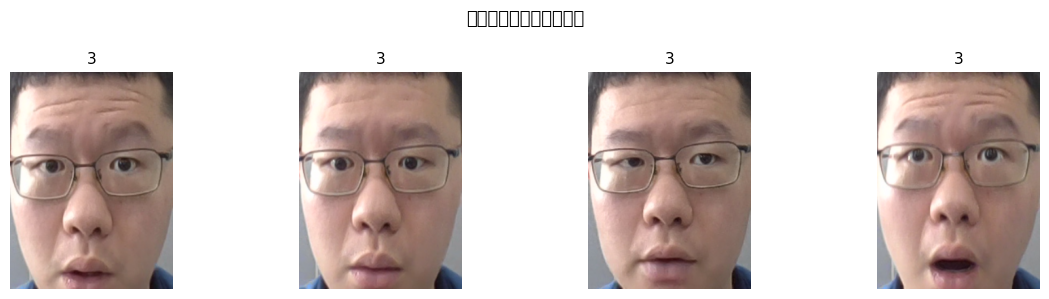

In [15]:
### 数据集可视化

import matplotlib.pyplot as plt
import numpy as np

# 获取类别名称
all_class = sorted([cla for cla in os.listdir(os.path.join(root, 'train')) 
                    if os.path.isdir(os.path.join(root, 'train', cla))])
class_names = {i: name for i, name in enumerate(all_class)}

print(f"类别数量: {len(class_names)}, 类别: {list(class_names.values())}")
print(f"训练集: {len(train_images_label)} 张, 验证集: {len(val_images_label)} 张")

# 随机展示4张训练集样本
fig, axes = plt.subplots(1, 4, figsize=(12, 3))

# 随机选择4个索引
random_indices = np.random.choice(len(train_dataset), size=4, replace=False)

for i, idx in enumerate(random_indices):
    img, label = train_dataset[idx]
    img_np = img.permute(1, 2, 0).numpy()
    
    axes[i].imshow(img_np)
    axes[i].set_title(f'{class_names[label]}', fontsize=11)
    axes[i].axis('off')

plt.suptitle('训练集样本展示（随机）', fontsize=13)
plt.tight_layout()
plt.show()

#### pytorch搭建卷积神经网络模型

首先搭建一个六层的卷积神经网络，4层卷积层，2层全连接。

输入为(240,320)彩色图，第一个层卷积层一个kernel/filter 的shape是3x3，共32个kernel/filter组成，relu函数作为激活函数，有padding。

接一个2x2的Maxpooling层.

第二个卷积层kernel3x3，共64个kernel/filter组成，relu函数作为激活函数，padding。

接一个2x2的Maxpooling层.

第三个卷积层kernel 3x3，共128个kernel/filter组成，relu函数作为激活函数，padding。

接一个2x2的Maxpooling层.

第四个卷积层kernel 3x3，共256个kernel/filter组成，relu函数作为激活函数，padding。

接一个2x2的Maxpooling层.


然后拉成一维，再跟100个神经元做一个全连接，relu函数作为激活函数。

最后，输出层3个神经元（多分类问题），softmax作为激活函数。

In [16]:
def conv_block(in_channels, out_channels, pool_kernel, pool_stride):
    """构建一个卷积块：卷积 -> BN -> ReLU -> 池化"""
    return nn.Sequential(
        #out_channels是指卷积核的个数, in_channels是输入通道数, padding=1保持输入输出尺寸一致
        nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
        nn.BatchNorm2d(out_channels),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=pool_kernel, stride=pool_stride)
    )

class CNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.features = nn.Sequential(
            #32个3*3*32的卷积核    得到240*320*32, pool下采样后变为120*160*32
            conv_block(3, 32, pool_kernel=2, pool_stride=2),
            #120*160*64, pool下采样后变为60*80*64
            conv_block(32, 64, pool_kernel=2, pool_stride=2),
            #pool下采样后变为15*20*128
            conv_block(64, 128, pool_kernel=4, pool_stride=4),
            #pool下采样后变为3*5*256=3840个像素点
            conv_block(128, 256, pool_kernel=4, pool_stride=4)
        )
        self.classifier = nn.Sequential(
            nn.Linear(3840, 100),
            nn.ReLU(),
            nn.Linear(100, 3)
        )

    def forward(self, x):
        x = self.features(x)
        # 将特征图展平成一维向量
        x = x.view(x.size(0), -1)
        
        x = self.classifier(x)
        return x
# net = CNN().to(device)
net = CNN()

**想一想：你会计算params的个数吗？**

### 训练模型
我们先定义一下训练一个epoch函数和评价的函数
model.train() 表示参数可被修改

model.eval() 表示参数不被修改

In [17]:
# model = net.to(device)
model = net
optimizer = optim.AdamW(model.parameters(), lr=0.001)
def train_one_epoch(model, optimizer, data_loader, device, epoch):
    model.train()
    loss_function = torch.nn.CrossEntropyLoss()
    accu_loss = torch.zeros(1).to(device)  # 累计损失
    accu_num = torch.zeros(1).to(device)   # 累计预测正确的样本数
    optimizer.zero_grad()

    sample_num = 0
    data_loader = tqdm(data_loader, file=sys.stdout)
    for step, data in enumerate(data_loader):
        images, labels = data
        print(images.shape)
        sample_num += images.shape[0]

        pred = model(images.to(device))
        #print(pred)
        pred_classes = torch.max(pred, dim=1)[1]
        #print(pred_classes)
        accu_num += torch.eq(pred_classes, labels.to(device)).sum()
        #print(accu_num)
        loss = loss_function(pred, labels.to(device))
        loss.backward()
        accu_loss += loss.detach()
        print(accu_loss)

        data_loader.desc = "[train epoch {}] loss: {:.3f}, acc: {:.3f}".format(epoch,
                                                                               accu_loss.item() / (step + 1),
                                                                               accu_num.item() / sample_num)

        if not torch.isfinite(loss):
            print('WARNING: non-finite loss, ending training ', loss)
            sys.exit(1)

        optimizer.step()
        optimizer.zero_grad()

    return accu_loss.item() / (step + 1), accu_num.item() / sample_num


@torch.no_grad()
def evaluate(model, data_loader, device, epoch):
    loss_function = torch.nn.CrossEntropyLoss()

    model.eval()

    accu_num = torch.zeros(1).to(device)   # 累计预测正确的样本数
    accu_loss = torch.zeros(1).to(device)  # 累计损失

    sample_num = 0
    data_loader = tqdm(data_loader, file=sys.stdout)
    for step, data in enumerate(data_loader):
        images, labels = data
        sample_num += images.shape[0]

        pred = model(images.to(device))
        pred_classes = torch.max(pred, dim=1)[1]
        accu_num += torch.eq(pred_classes, labels.to(device)).sum()

        loss = loss_function(pred, labels.to(device))
        accu_loss += loss

        data_loader.desc = "[valid epoch {}] loss: {:.3f}, acc: {:.3f}".format(epoch,
                                                                               accu_loss.item() / (step+1),
                                                                               accu_num.item() / sample_num)

    return accu_loss.item() / (step + 1), accu_num.item() / sample_num


### 开始训练
每10轮保存一次模型

In [19]:
epochs = 20
for epoch in range(epochs):
        # train
        train_loss, train_acc = train_one_epoch(model=model,
                                                optimizer=optimizer,
                                                data_loader=train_loader,
                                                device=None,
                                                epoch=epoch)

        # validate
        val_loss, val_acc = evaluate(model=model,
                                     data_loader=val_loader,
                                     device=None,
                                     epoch=epoch)
        

  0%|          | 0/57 [00:00<?, ?it/s]torch.Size([32, 3, 320, 240])
tensor([0.0486])
[train epoch 0] loss: 0.049, acc: 0.969:   2%|▏         | 1/57 [00:02<02:27,  2.63s/it]torch.Size([32, 3, 320, 240])
tensor([0.0721])
[train epoch 0] loss: 0.036, acc: 0.984:   4%|▎         | 2/57 [00:05<02:25,  2.64s/it]torch.Size([32, 3, 320, 240])
tensor([0.0835])
[train epoch 0] loss: 0.028, acc: 0.990:   5%|▌         | 3/57 [00:07<02:22,  2.64s/it]torch.Size([32, 3, 320, 240])
tensor([0.1136])
[train epoch 0] loss: 0.028, acc: 0.992:   7%|▋         | 4/57 [00:10<02:19,  2.64s/it]torch.Size([32, 3, 320, 240])
tensor([0.2855])
[train epoch 0] loss: 0.057, acc: 0.975:   9%|▉         | 5/57 [00:13<02:18,  2.66s/it]torch.Size([32, 3, 320, 240])
tensor([0.3179])
[train epoch 0] loss: 0.053, acc: 0.979:  11%|█         | 6/57 [00:15<02:16,  2.67s/it]torch.Size([32, 3, 320, 240])
tensor([0.3313])
[train epoch 0] loss: 0.047, acc: 0.982:  12%|█▏        | 7/57 [00:18<02:12,  2.65s/it]torch.Size([32, 3, 320, 

In [20]:
#torch.save(model, "./model.pth")

torch.save(model.state_dict(), "./model.pth")

### 用Opencv读取人脸检测、表情识别pt模型并推理
在OpenCV那一节当中，我们学了如何使用dnn中的推理模块读取人脸检测模型，进行人脸检测，画出人脸框。训练了我们自己的人脸表情识别模型后，我们可以将其加入，在检测好人脸之后，在人脸区域运用表情识别推理出人的表情，并显示。

In [21]:
import cv2
import numpy as np
import time

model_bin = "./models/models/face_detector/opencv_face_detector_uint8.pb"
config_text = "./models/models/face_detector/opencv_face_detector.pbtxt";

class_names = ['normal','happy','surprise']

#加载训练好的模型
#net = torch.load('model.pth')
net = CNN()
net.load_state_dict(torch.load('model.pth'))
# model.eval()

<All keys matched successfully>

### 实时视频读取测试

In [30]:
import cv2
import numpy as np


def get_face_data_realtime(): 
    # 加载用于检测人脸的模型文件
    net_face = cv2.dnn.readNetFromTensorflow(model_bin, config=config_text)
    font = cv2.FONT_HERSHEY_SIMPLEX
    
    # 打开默认摄像头
    cap = cv2.VideoCapture(0)
    
    if not cap.isOpened():
        print("Error: Could not open video stream.")

    while True:
        # 逐帧捕获
        ret, frame = cap.read()
        if not ret:
            print("Failed to grab frame")
            break

        h, w, c = frame.shape
        
        # 为人脸检测创建 blob 特定格式；1.0: 缩放因子；(104.0, 177.0, 123.0): RGB均值减法的值。
        blobImage = cv2.dnn.blobFromImage(frame, 1.0, (300, 300), (104.0, 177.0, 123.0), False, False)
        net_face.setInput(blobImage)   #将上一步生成的 blob 设置为神经网络 net_face 的输入
        cvOut = net_face.forward()

        # 检测人脸位置，[batch, class_num, N, 7] 的数组，其中 N 是检测到的人脸数量，
        # 7 个值分别表示：【图像id，类别，置信度，边界框左上角x坐标/y坐标，右下角x坐标/y坐标】，4个坐标都归一化到（0，1）之间了
        for detection in cvOut[0,0,:,:]:  #遍历每一个人脸的7个值
            score = float(detection[2])  #置信度
            if score > 0.5:
                left = int(detection[3]*w)  #左上角x坐标
                top = int(detection[4]*h)  #左上角y坐标
                right = int(detection[5]*w)  #右下角x坐标
                bottom = int(detection[6]*h)  #右下角y坐标

                # 确保边界框在图像范围内
                left = max(0, left)
                top = max(0, top)
                right = min(w - 1, right)
                bottom = min(h - 1, bottom)

                # 绘制矩形框
                cv2.rectangle(frame, (left, top), (right, bottom), (255, 0, 0), 2)
                
                # 截取人脸图像用于表情识别
                face_img = frame[top:bottom, left:right]

                if face_img.size > 0:
                    # 将 BGR 图像转为 RGB 以便模型处理
                    face_img_rgb = cv2.cvtColor(face_img, cv2.COLOR_BGR2RGB)
                    
                    # 调整大小并转换为 tensor
                    face_img_resized = cv2.resize(face_img_rgb, (320, 240))
                    img_tensor = transform(face_img_resized)
                    
                    # img_tensor = img_tensor.unsqueeze(0).to(device)
                    img_tensor = img_tensor.unsqueeze(0)
                    # 进行推理
                    with torch.no_grad():
                        prediction = net(img_tensor)
                        idx = torch.argmax(prediction, dim=1).item()
                        result = class_names[idx]
                    
                    # 在画面上显示结果
                    cv2.putText(frame, result, (left, top - 10), font, 0.9, (255, 0, 0), 2, cv2.LINE_AA)
        
        # 显示结果帧
        cv2.imshow('Real-time Face Detection', frame)

        # 按 'q' 键退出循环
        if cv2.waitKey(1) & 0xFF == ord('q'):
            break
            
    # 释放摄像头并关闭所有窗口
    cap.release()
    cv2.destroyAllWindows()
    cv2.waitKey(1)

if __name__=='__main__':
    get_face_data_realtime()

In [23]:
def get_face_data(): 
    # 加载模型文件，用于检测人脸
    net_face = cv2.dnn.readNetFromTensorflow(model_bin, config=config_text)
    
    
    font = cv2.FONT_HERSHEY_SIMPLEX
    
    camera = cv2.VideoCapture(0)
    count = 1
    while True:
        ret, frame = camera.read()
        h, w, c = frame.shape
        blobImage = cv2.dnn.blobFromImage(frame, 1.0, (300, 300), (104.0, 177.0, 123.0), False, False);
        net_face.setInput(blobImage)
        cvOut = net_face.forward()
       # 检测人脸位置
        for detection in cvOut[0,0,:,:]:
            score = float(detection[2])
            objIndex = int(detection[1])
            if score > 0.5:
                left = int(detection[3]*w)
                top = int(detection[4]*h)
                right = int(detection[5]*w)
                bottom = int(detection[6]*h)
             
                img = cv2.rectangle(frame,(left, top), (right, bottom),(255, 0, 0), 2)
                start = time.time()
                # 根据检测结果截取图片并调整截取后的图片大小，为进一步做表情识别做准备
                ### start code
                f = frame[top:bottom, left:right]
                
                ##将检测到的人脸resize成跟训练集图像同样大小
                f = cv2.resize(frame[top:bottom, left:right], (240, 320))
                ##将图像变换成tensor
                print(f.shape)
                ##将图像由[c,h,w] 的tensor 变换成[b,c,h,w]的tensor 以符合dataloader训练集的shape
                img_tensor = transform(f)
                #img_tensor = trans(f)
                print(img_tensor.shape)
                #img_tensor.to(device)
                img_tensor = img_tensor.unsqueeze(0)
                print(img_tensor.shape)
                  
                ## 进行推理
                prediction = net(img_tensor)
                ## 将推理结果取回cpu
                ### end code
                prediction = prediction.detach()
                end = time.time()
                fps = 1/(end - start)
                fps_label = "Throughput: %.2f FPS" % fps
                cv2.putText(frame, fps_label, (10, 25), cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 0, 255), 2)
                
                print(np.array(prediction))
                idx = np.argmax(np.array(prediction))

                result = class_names[idx]
                cv2.putText(frame, result, (left,top), font, 2, (255, 0, 0), 2, cv2.LINE_AA)
                count += 1
             
        cv2.imshow('pic', frame)
        # 停止程序
        if cv2.waitKey(10) & 0xff == ord(' '):
            break
    camera.release()
    cv2.destroyAllWindows()
 
if __name__=='__main__':
    get_face_data()

(320, 240, 3)
torch.Size([3, 320, 240])
torch.Size([1, 3, 320, 240])
[[ 0.6948994  -0.67792875 -2.8185763 ]]
(320, 240, 3)
torch.Size([3, 320, 240])
torch.Size([1, 3, 320, 240])


C:\Users\86135\AppData\Local\Temp\ipykernel_10808\991106997.py:54: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  print(np.array(prediction))
C:\Users\86135\AppData\Local\Temp\ipykernel_10808\991106997.py:55: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  idx = np.argmax(np.array(prediction))


[[ 4.1341047 -2.584029  -4.3692303]]
(320, 240, 3)
torch.Size([3, 320, 240])
torch.Size([1, 3, 320, 240])
[[ 5.1052556 -3.2905939 -4.6053333]]
(320, 240, 3)
torch.Size([3, 320, 240])
torch.Size([1, 3, 320, 240])
[[ 3.5284953 -1.6648512 -4.378551 ]]
(320, 240, 3)
torch.Size([3, 320, 240])
torch.Size([1, 3, 320, 240])
[[ 3.9544637 -1.7961756 -4.6520433]]
(320, 240, 3)
torch.Size([3, 320, 240])
torch.Size([1, 3, 320, 240])
[[ 3.4037838 -2.1489027 -3.971799 ]]
(320, 240, 3)
torch.Size([3, 320, 240])
torch.Size([1, 3, 320, 240])
[[ 3.7598546 -2.0877964 -4.3020654]]
(320, 240, 3)
torch.Size([3, 320, 240])
torch.Size([1, 3, 320, 240])
[[ 3.193889  -2.388756  -3.6456184]]
(320, 240, 3)
torch.Size([3, 320, 240])
torch.Size([1, 3, 320, 240])
[[ 3.848626  -2.5018837 -4.0797606]]
(320, 240, 3)
torch.Size([3, 320, 240])
torch.Size([1, 3, 320, 240])
[[ 3.2161376 -2.8822577 -3.3475075]]
(320, 240, 3)
torch.Size([3, 320, 240])
torch.Size([1, 3, 320, 240])
[[ 0.11725238 -1.3785385  -1.9472862 ]]
(320, 

### torch中自带网络模型
如果我们不自己搭建卷积神经网络，也可以直接导入一些成熟的网络模型，Torch中的models包中提供了带有预训练权值的深度学习模型，这些模型可以用来进行预测、特征提取和微调（fine-tuning).
>Xception
>VGG16
>VGG19
>ResNet, ResNetV2, ResNeXt
>InceptionV3
>InceptionResNetV2
>MobileNet
>MobileNetV2
>DenseNet
>NASNet

In [24]:
net_res = torchvision.models.resnet18(pretrained = True)# 这里的True意味着是经过官方预训练的,模型收敛速度要快的多得多
fc_inputs=net_res.fc.in_features
net_res.fc= nn.Linear(fc_inputs,3) #这里的3需要改成你自己数据集的需要分类的种类

e:\anaconda\envs\torch\lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
e:\anaconda\envs\torch\lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to C:\Users\86135/.cache\torch\hub\checkpoints\resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:04<00:00, 9.99MB/s]


In [26]:
model_res = net_res.to(device)
pg = [p for p in model_res.parameters() if p.requires_grad]
optimizer = optim.AdamW(pg, lr=0.001, weight_decay=5E-2)

In [17]:
epochs = 2
for epoch in range(epochs+1):
        # train
        train_loss, train_acc = train_one_epoch(model=model_res,
                                                optimizer=optimizer,
                                                data_loader=train_loader,
                                                device=device,
                                                epoch=epoch)

        # validate
        val_loss, val_acc = evaluate(model=model_res,
                                     data_loader=val_loader,
                                     device=device,
                                     epoch=epoch)


  0%|          | 0/22 [00:00<?, ?it/s]torch.Size([32, 3, 320, 240])
tensor([1.1466])
[train epoch 0] loss: 1.147, acc: 0.469:   5%|▍         | 1/22 [00:03<01:06,  3.15s/it]torch.Size([32, 3, 320, 240])
tensor([1.7440])
[train epoch 0] loss: 0.872, acc: 0.656:   9%|▉         | 2/22 [00:06<01:01,  3.09s/it]torch.Size([32, 3, 320, 240])
tensor([2.4322])
[train epoch 0] loss: 0.811, acc: 0.646:  14%|█▎        | 3/22 [00:09<00:56,  2.97s/it]torch.Size([32, 3, 320, 240])
tensor([3.3116])
[train epoch 0] loss: 0.828, acc: 0.680:  18%|█▊        | 4/22 [00:11<00:51,  2.88s/it]torch.Size([32, 3, 320, 240])
tensor([3.6760])
[train epoch 0] loss: 0.735, acc: 0.719:  23%|██▎       | 5/22 [00:14<00:47,  2.81s/it]torch.Size([32, 3, 320, 240])
tensor([4.0382])
[train epoch 0] loss: 0.673, acc: 0.729:  27%|██▋       | 6/22 [00:17<00:44,  2.80s/it]torch.Size([32, 3, 320, 240])
tensor([4.3923])
[train epoch 0] loss: 0.627, acc: 0.750:  32%|███▏      | 7/22 [00:19<00:41,  2.77s/it]torch.Size([32, 3, 320, 

In [27]:
torch.save(model_res.state_dict(), "./model-res.pth")
#torch.save(model_res,"./resmodel.pth")

In [29]:
#net_res = torch.load('./model-res.pth')
net_res.load_state_dict(torch.load('./model-res.pth')) 

<All keys matched successfully>